# English-to-Hindi Transformer From Scratch in PyTorch

**T4 high-quality final version.**

This notebook builds a complete encoder-decoder Transformer for English-to-Hindi neural machine translation without `nn.Transformer`, without HuggingFace Trainer, and without hiding the core mechanics.

This version is tuned for Colab T4 quality/stability rather than tiny demos:

- stricter noisy-sample filtering
- larger Transformer: `d_model=256`, 3 encoder layers, 3 decoder layers
- GELU feed-forward activation
- target embedding/output projection weight tying
- label smoothing
- gradient accumulation
- longer warmup
- beam-search decoding
- self-contained BLEU + chrF evaluation

Important honesty: this is still a from-scratch word-level educational NMT model. It will improve a lot over the tiny demo model, but it will not match Google Translate or pretrained models. For truly fluent production translation, use subword tokenization plus larger training and/or pretrained multilingual models.

## 1. Imports & Setup

We use PyTorch building blocks such as `nn.Linear`, `nn.Embedding`, and `nn.ModuleList`, but we manually implement Transformer-specific mechanics: attention, masks, positional encoding, layer normalization, encoder blocks, decoder blocks, training, and decoding.

No `nn.Transformer` is used.

In [1]:
from __future__ import annotations

import math
import os
import random
import re
import time
import zipfile
import html
import unicodedata
from collections import Counter, defaultdict
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print("PyTorch:", torch.__version__)

PyTorch: 2.10.0+cu128


## 2. GPU Setup

For reproducibility we seed Python, NumPy, and PyTorch. For Colab T4, mixed precision is useful because matrix multiplications become faster and use less memory. We still keep all tensor shape checks explicit.

In [2]:
def set_seed(seed: int = 42) -> None:
    """Make experiments more reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    """Return CUDA if available, otherwise CPU."""
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print("CUDA device:", torch.cuda.get_device_name(0))
        print("CUDA capability:", torch.cuda.get_device_capability(0))
    else:
        device = torch.device("cpu")
        print("CUDA not available; running on CPU.")
    return device


def gpu_memory(prefix: str = "") -> None:
    """Print current and peak CUDA memory in MB."""
    if not torch.cuda.is_available():
        return
    allocated = torch.cuda.memory_allocated() / 1024**2
    reserved = torch.cuda.memory_reserved() / 1024**2
    max_allocated = torch.cuda.max_memory_allocated() / 1024**2
    print(f"{prefix}GPU memory | allocated={allocated:.1f} MB | reserved={reserved:.1f} MB | peak={max_allocated:.1f} MB")


set_seed(42)
device = get_device()
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

CUDA device: Tesla T4
CUDA capability: (7, 5)


## 3. Dataset Loading

The OPUS-style dataset is expected to contain parallel line-aligned files:

```text
opus.en-hi-train.en  -> English train source
opus.en-hi-train.hi  -> Hindi train target
opus.en-hi-dev.en    -> English validation source
opus.en-hi-dev.hi    -> Hindi validation target
opus.en-hi-test.en   -> English test source
opus.en-hi-test.hi   -> Hindi test target
```

Line `i` in the English file must align with line `i` in the Hindi file. This alignment is the first thing we verify.

In [3]:
# =============================
# Dataset path configuration
# =============================

# In Colab, set this to your uploaded ZIP path, for example:
# DATASET_ZIP_PATH = "/content/hindi_to_english_dataset.zip"
DATASET_ZIP_PATH = ""

# If the dataset is already extracted, set this to the folder containing the six files.
# This local fallback matches the files you provided on your machine.
DATASET_DIR = "/Users/sethiyapreet298/Downloads/hindi to english dataset"

# Colab extraction location if DATASET_ZIP_PATH is set.
EXTRACT_DIR = "/content/en_hi_dataset"

EXPECTED_FILES = {
    "train": ("opus.en-hi-train.en", "opus.en-hi-train.hi"),
    "dev": ("opus.en-hi-dev.en", "opus.en-hi-dev.hi"),
    "test": ("opus.en-hi-test.en", "opus.en-hi-test.hi"),
}


def inspect_zip_structure(zip_path: str, max_names: int = 30) -> None:
    """Print a compact view of files inside a dataset ZIP."""
    if not zip_path:
        print("No ZIP path configured.")
        return
    zip_file = Path(zip_path)
    if not zip_file.exists():
        print(f"ZIP not found: {zip_file}")
        return
    with zipfile.ZipFile(zip_file, "r") as archive:
        names = archive.namelist()
    print(f"ZIP contains {len(names)} entries. First {min(max_names, len(names))}:")
    for name in names[:max_names]:
        print("  ", name)


def extract_zip_if_needed(zip_path: str, extract_dir: str) -> Optional[Path]:
    """Extract the ZIP if a path is provided and return the extraction directory."""
    if not zip_path:
        return None
    zip_file = Path(zip_path)
    if not zip_file.exists():
        raise FileNotFoundError(f"Dataset ZIP not found: {zip_file}")
    extract_root = Path(extract_dir)
    extract_root.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_file, "r") as archive:
        archive.extractall(extract_root)
    print(f"Extracted {zip_file} -> {extract_root}")
    return extract_root


def discover_parallel_files(dataset_dir: str, extracted_dir: Optional[Path] = None) -> dict[str, tuple[Path, Path]]:
    """Find train/dev/test English-Hindi files in a folder tree."""
    candidate_roots = []
    if dataset_dir:
        candidate_roots.append(Path(dataset_dir))
    if extracted_dir is not None:
        candidate_roots.append(extracted_dir)
    candidate_roots.extend([Path("/content"), Path.cwd()])

    for root in candidate_roots:
        if not root.exists():
            continue
        found: dict[str, tuple[Path, Path]] = {}
        for split, (en_name, hi_name) in EXPECTED_FILES.items():
            en_matches = list(root.rglob(en_name))
            hi_matches = list(root.rglob(hi_name))
            if en_matches and hi_matches:
                found[split] = (en_matches[0], hi_matches[0])
        if set(found) == {"train", "dev", "test"}:
            print(f"Discovered dataset under: {root}")
            for split, (en_path, hi_path) in found.items():
                print(f"  {split}: {en_path.name}, {hi_path.name}")
            return found

    raise FileNotFoundError(
        "Could not find all six OPUS files. Set DATASET_ZIP_PATH or DATASET_DIR correctly."
    )


inspect_zip_structure(DATASET_ZIP_PATH)
extracted_dir = extract_zip_if_needed(DATASET_ZIP_PATH, EXTRACT_DIR)
split_paths = discover_parallel_files(DATASET_DIR, extracted_dir)

No ZIP path configured.
Discovered dataset under: /content
  train: opus.en-hi-train.en, opus.en-hi-train.hi
  dev: opus.en-hi-dev.en, opus.en-hi-dev.hi
  test: opus.en-hi-test.en, opus.en-hi-test.hi


## 4. EDA & Preprocessing

Before coding the model, we inspect the text itself.

We check:

- strict UTF-8 decoding
- byte size and line counts
- missing values / empty lines
- exact duplicate pairs
- source-only and target-only duplicates
- sentence length distributions
- copied English targets
- hidden zero-width characters
- replacement characters like `�`
- URLs and email addresses
- extreme source-target length ratios

Preprocessing decisions are conservative:

1. Keep raw files untouched.
2. Normalize Unicode using NFC.
3. Unescape HTML entities like `&quot;`.
4. Remove invisible zero-width/BOM characters.
5. Collapse repeated whitespace.
6. Remove exact duplicate normalized pairs.
7. Remove identical source-target rows.
8. Remove rows with replacement characters.
9. Remove URL/email-heavy rows for the baseline.
10. Remove target rows that contain Latin text but no Devanagari.
11. Remove examples too long for `max_seq_len = 64`.
12. Remove extreme source-target token-ratio rows.
13. Remove exact dev/test overlap from test.

We do **not** blindly remove all short examples. Subtitle corpora contain valid short translations like "Yes." -> "हाँ.".

In [4]:
ZERO_WIDTH_TRANSLATION = dict.fromkeys(map(ord, ["\u200b", "\u200c", "\u200d", "\ufeff"]), None)
URL_PATTERN = re.compile(r"https?\s*:?\s*/\s*/|https?://|www\.", re.IGNORECASE)
EMAIL_PATTERN = re.compile(r"\b[\w.%-]+\s*@\s*[\w.-]+\s*\.\s*[A-Za-z]{2,}\b")
LATIN_PATTERN = re.compile(r"[A-Za-z]")
DEVANAGARI_PATTERN = re.compile(r"[\u0900-\u097F]")
HTML_PATTERN = re.compile(r"<[^>]+>|&(?:amp|lt|gt|quot|apos|nbsp);", re.IGNORECASE)


def normalize_text(text: str, lowercase_english: bool = False) -> str:
    """Normalize one raw text line without changing its meaning."""
    text = html.unescape(text)
    text = unicodedata.normalize("NFC", text)
    text = text.translate(ZERO_WIDTH_TRANSLATION)
    text = text.replace("\u00a0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    if lowercase_english:
        text = text.lower()
    return text


def read_lines_strict(path: Path) -> list[str]:
    """Read UTF-8 lines, reporting encoding damage instead of crashing.

    Some dataset copies contain truncated multi-byte sequences. We first try
    strict UTF-8 so the issue is visible. If that fails, we decode with
    replacement characters. Later preprocessing removes rows containing `�`,
    so corrupt text does not become training signal.
    """
    raw = path.read_bytes()
    try:
        text = raw.decode("utf-8", errors="strict")
    except UnicodeDecodeError as exc:
        print(f"[encoding warning] {path.name}: {exc}")
        print("[encoding warning] Decoding with errors='replace'; affected rows will be flagged/removed.")
        text = raw.decode("utf-8", errors="replace")
    return text.splitlines()


def inspect_file(path: Path) -> dict[str, Any]:
    """Return byte-level and line-level file health information."""
    raw = path.read_bytes()
    try:
        raw.decode("utf-8", errors="strict")
        utf8_ok = True
        error = None
    except UnicodeDecodeError as exc:
        utf8_ok = False
        error = str(exc)
    return {
        "path": str(path),
        "bytes": len(raw),
        "utf8_strict_ok": utf8_ok,
        "decode_error": error,
        "nul_bytes": raw.count(b"\x00"),
        "bom_at_start": raw.startswith(b"\xef\xbb\xbf"),
        "line_count": len(raw.decode("utf-8", errors="replace").splitlines()),
    }


def basic_token_count(text: str) -> int:
    """Whitespace token count for EDA, not the final model tokenizer."""
    return len(text.split())


def quantiles(values: list[int | float]) -> dict[str, float]:
    """Compute robust distribution statistics."""
    if not values:
        return {}
    values_sorted = sorted(values)
    def q(p: float) -> float:
        idx = round((len(values_sorted) - 1) * p)
        return float(values_sorted[idx])
    return {
        "min": float(values_sorted[0]),
        "p05": q(0.05),
        "p25": q(0.25),
        "median": q(0.50),
        "p75": q(0.75),
        "p90": q(0.90),
        "p95": q(0.95),
        "p99": q(0.99),
        "max": float(values_sorted[-1]),
        "mean": float(np.mean(values_sorted)),
    }


def analyze_split(en_path: Path, hi_path: Path, split: str, sample_limit: int = 5) -> dict[str, Any]:
    """Analyze one aligned source-target split."""
    en_lines = read_lines_strict(en_path)
    hi_lines = read_lines_strict(hi_path)
    if len(en_lines) != len(hi_lines):
        raise ValueError(f"Line mismatch in {split}: en={len(en_lines)} hi={len(hi_lines)}")

    pair_counter: Counter[tuple[str, str]] = Counter()
    en_counter: Counter[str] = Counter()
    hi_counter: Counter[str] = Counter()
    en_lengths, hi_lengths, ratios = [], [], []
    flags: Counter[str] = Counter()
    samples: dict[str, list[dict[str, Any]]] = defaultdict(list)

    for line_no, (en_raw, hi_raw) in enumerate(zip(en_lines, hi_lines), start=1):
        en = normalize_text(en_raw)
        hi = normalize_text(hi_raw)
        en_toks = basic_token_count(en)
        hi_toks = basic_token_count(hi)
        en_lengths.append(en_toks)
        hi_lengths.append(hi_toks)
        ratios.append((hi_toks + 1) / (en_toks + 1))
        pair_counter[(en, hi)] += 1
        en_counter[en] += 1
        hi_counter[hi] += 1

        row_flags = []
        if not en or not hi:
            row_flags.append("empty_side")
        if "\ufffd" in en or "\ufffd" in hi:
            row_flags.append("replacement_char")
        if en == hi and en:
            row_flags.append("identical_src_tgt")
        if URL_PATTERN.search(en) or URL_PATTERN.search(hi):
            row_flags.append("url")
        if EMAIL_PATTERN.search(en) or EMAIL_PATTERN.search(hi):
            row_flags.append("email")
        if HTML_PATTERN.search(en_raw) or HTML_PATTERN.search(hi_raw):
            row_flags.append("html_entity_or_tag")
        if any(ch in en_raw + hi_raw for ch in ["\u200b", "\u200c", "\u200d", "\ufeff"]):
            row_flags.append("zero_width_or_bom")
        if en_toks > 120 or hi_toks > 120:
            row_flags.append("very_long")
        if en_toks <= 2 or hi_toks <= 2:
            row_flags.append("very_short_fragment")
        if en_toks > 0 and hi_toks > 0 and ((hi_toks + 1) / (en_toks + 1) > 4.0 or (hi_toks + 1) / (en_toks + 1) < 0.25):
            row_flags.append("extreme_token_ratio")
        if LATIN_PATTERN.search(hi) and DEVANAGARI_PATTERN.search(hi) is None:
            row_flags.append("target_latin_no_devanagari")

        for flag in row_flags:
            flags[flag] += 1
            if len(samples[flag]) < sample_limit:
                samples[flag].append({"line": line_no, "en": en_raw, "hi": hi_raw})

    duplicate_pair_extra = sum(count - 1 for count in pair_counter.values() if count > 1)
    duplicate_en_extra = sum(count - 1 for count in en_counter.values() if count > 1)
    duplicate_hi_extra = sum(count - 1 for count in hi_counter.values() if count > 1)

    return {
        "split": split,
        "en_file": inspect_file(en_path),
        "hi_file": inspect_file(hi_path),
        "rows": len(en_lines),
        "duplicate_pair_extra_rows": duplicate_pair_extra,
        "duplicate_en_extra_rows": duplicate_en_extra,
        "duplicate_hi_extra_rows": duplicate_hi_extra,
        "en_token_lengths": quantiles(en_lengths),
        "hi_token_lengths": quantiles(hi_lengths),
        "target_source_token_ratio": quantiles(ratios),
        "flags": dict(flags.most_common()),
        "samples": dict(samples),
    }


eda_reports = {}
for split, (en_path, hi_path) in split_paths.items():
    eda_reports[split] = analyze_split(en_path, hi_path, split)
    report = eda_reports[split]
    print(f"\n=== {split.upper()} ===")
    print("rows:", report["rows"])
    print("en utf8:", report["en_file"]["utf8_strict_ok"], "hi utf8:", report["hi_file"]["utf8_strict_ok"])
    print("duplicate_pair_extra_rows:", report["duplicate_pair_extra_rows"])
    print("en length median/p95/max:", report["en_token_lengths"]["median"], report["en_token_lengths"]["p95"], report["en_token_lengths"]["max"])
    print("hi length median/p95/max:", report["hi_token_lengths"]["median"], report["hi_token_lengths"]["p95"], report["hi_token_lengths"]["max"])
    print("top flags:", list(report["flags"].items())[:8])


=== TRAIN ===
rows: 534319
en utf8: True hi utf8: True
duplicate_pair_extra_rows: 159724
en length median/p95/max: 6.0 41.0 321.0
hi length median/p95/max: 7.0 50.0 319.0
top flags: [('very_short_fragment', 145204), ('target_latin_no_devanagari', 8769), ('identical_src_tgt', 5986), ('extreme_token_ratio', 4393), ('very_long', 1362), ('zero_width_or_bom', 591), ('html_entity_or_tag', 556), ('url', 407)]

=== DEV ===
rows: 2000
en utf8: True hi utf8: True
duplicate_pair_extra_rows: 76
en length median/p95/max: 7.0 43.0 291.0
hi length median/p95/max: 7.0 52.0 351.0
top flags: [('very_short_fragment', 450), ('target_latin_no_devanagari', 36), ('identical_src_tgt', 16), ('email', 10), ('very_long', 6), ('zero_width_or_bom', 5), ('extreme_token_ratio', 5), ('html_entity_or_tag', 2)]

=== TEST ===
rows: 2000
en utf8: True hi utf8: True
duplicate_pair_extra_rows: 57
en length median/p95/max: 7.0 45.0 147.0
hi length median/p95/max: 7.0 58.0 185.0
top flags: [('very_short_fragment', 452), ('t

In [5]:
@dataclass(frozen=True)
class PreprocessingConfig:
    """Cleaning policy for the first trainable baseline."""
    max_seq_len: int = 64
    lowercase_english: bool = False
    min_token_ratio: float = 0.25
    max_token_ratio: float = 4.0
    remove_duplicate_pairs: bool = True
    remove_identical_source_target: bool = True
    remove_replacement_char: bool = True
    remove_url_or_email: bool = True
    remove_target_latin_without_devanagari: bool = True
    remove_dev_test_overlap_from_test: bool = True


def pair_key(en: str, hi: str) -> str:
    """Stable exact normalized pair key."""
    return en + "\t" + hi


def should_remove_pair(en: str, hi: str, config: PreprocessingConfig) -> list[str]:
    """Return all reasons a pair should be removed."""
    reasons = []
    en_tokens = en.split()
    hi_tokens = hi.split()

    # Reserve room for <bos> and <eos> later.
    max_raw_tokens = config.max_seq_len - 2

    if not en or not hi:
        reasons.append("empty_after_normalization")
    if config.remove_replacement_char and ("\ufffd" in en or "\ufffd" in hi):
        reasons.append("replacement_char")
    if config.remove_identical_source_target and en == hi:
        reasons.append("identical_src_tgt")
    if len(en_tokens) > max_raw_tokens or len(hi_tokens) > max_raw_tokens:
        reasons.append("too_long_for_max_seq_len")
    if en_tokens and hi_tokens:
        ratio = (len(hi_tokens) + 1) / (len(en_tokens) + 1)
        if ratio < config.min_token_ratio or ratio > config.max_token_ratio:
            reasons.append("extreme_token_ratio")
    if config.remove_url_or_email and (
        URL_PATTERN.search(en) or URL_PATTERN.search(hi) or EMAIL_PATTERN.search(en) or EMAIL_PATTERN.search(hi)
    ):
        reasons.append("url_or_email")
    if config.remove_target_latin_without_devanagari and LATIN_PATTERN.search(hi) and DEVANAGARI_PATTERN.search(hi) is None:
        reasons.append("target_latin_no_devanagari")
    return reasons


def load_and_clean_split(en_path: Path, hi_path: Path, config: PreprocessingConfig) -> tuple[list[tuple[str, str]], Counter[str]]:
    """Load, normalize, filter, and deduplicate one split."""
    en_lines = read_lines_strict(en_path)
    hi_lines = read_lines_strict(hi_path)
    assert len(en_lines) == len(hi_lines), "Parallel files must have matching line counts."

    kept: list[tuple[str, str]] = []
    seen: set[str] = set()
    removal_counts: Counter[str] = Counter()

    for en_raw, hi_raw in zip(en_lines, hi_lines):
        en = normalize_text(en_raw, lowercase_english=config.lowercase_english)
        hi = normalize_text(hi_raw, lowercase_english=False)
        reasons = should_remove_pair(en, hi, config)
        key = pair_key(en, hi)
        if config.remove_duplicate_pairs and key in seen:
            reasons.append("duplicate_pair_within_split")
        if reasons:
            removal_counts.update(reasons)
            continue
        seen.add(key)
        kept.append((en, hi))
    return kept, removal_counts


preprocess_config = PreprocessingConfig(max_seq_len=64, lowercase_english=False)
print(preprocess_config)

clean_pairs: dict[str, list[tuple[str, str]]] = {}
preprocess_reports = {}

for split, (en_path, hi_path) in split_paths.items():
    pairs, removals = load_and_clean_split(en_path, hi_path, preprocess_config)
    clean_pairs[split] = pairs
    preprocess_reports[split] = {
        "raw_rows": eda_reports[split]["rows"],
        "kept_before_cross_split": len(pairs),
        "removed_before_cross_split": eda_reports[split]["rows"] - len(pairs),
        "removal_counts_nonexclusive": dict(removals.most_common()),
    }

if preprocess_config.remove_dev_test_overlap_from_test:
    dev_keys = {pair_key(en, hi) for en, hi in clean_pairs["dev"]}
    before = len(clean_pairs["test"])
    clean_pairs["test"] = [(en, hi) for en, hi in clean_pairs["test"] if pair_key(en, hi) not in dev_keys]
    preprocess_reports["test"]["exact_dev_overlap_removed"] = before - len(clean_pairs["test"])

for split in ["train", "dev", "test"]:
    print(f"\n{split}: raw={preprocess_reports[split]['raw_rows']}, clean={len(clean_pairs[split])}")
    print("removals:", preprocess_reports[split]["removal_counts_nonexclusive"])

print("\nSample cleaned pairs:")
for en, hi in clean_pairs["train"][:5]:
    print("EN:", en)
    print("HI:", hi)
    print("---")

PreprocessingConfig(max_seq_len=64, lowercase_english=False, min_token_ratio=0.25, max_token_ratio=4.0, remove_duplicate_pairs=True, remove_identical_source_target=True, remove_replacement_char=True, remove_url_or_email=True, remove_target_latin_without_devanagari=True, remove_dev_test_overlap_from_test=True)

train: raw=534319, clean=350677
removals: {'duplicate_pair_within_split': 154630, 'too_long_for_max_seq_len': 15155, 'target_latin_no_devanagari': 8769, 'identical_src_tgt': 5986, 'extreme_token_ratio': 4393, 'url_or_email': 530, 'replacement_char': 18}

dev: raw=2000, clean=1818
removals: {'too_long_for_max_seq_len': 71, 'duplicate_pair_within_split': 67, 'target_latin_no_devanagari': 36, 'identical_src_tgt': 16, 'url_or_email': 11, 'extreme_token_ratio': 5}

test: raw=2000, clean=1724
removals: {'too_long_for_max_seq_len': 86, 'duplicate_pair_within_split': 53, 'target_latin_no_devanagari': 42, 'identical_src_tgt': 26, 'url_or_email': 12, 'extreme_token_ratio': 6}

Sample clean

## 5. Tokenization

A production NMT system often uses subword tokenization such as BPE or SentencePiece. Here we use a transparent word/punctuation tokenizer so every step remains inspectable.

English tokenizer:

- groups alphabetic words, including simple contractions
- keeps numbers
- keeps punctuation as individual tokens

Hindi tokenizer:

- groups Devanagari spans
- keeps Latin placeholders and numbers when they survive cleaning
- keeps punctuation as tokens

This is not the best tokenizer for final BLEU, but it is excellent for understanding the Transformer mechanics.

In [6]:
EN_TOKEN_PATTERN = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?|\d+(?:\.\d+)?|[^\s]")
HI_TOKEN_PATTERN = re.compile(r"[\u0900-\u097F]+|[A-Za-z]+|\d+(?:\.\d+)?|[^\s]")


def tokenize_en(text: str) -> list[str]:
    """Tokenize English into words, numbers, and punctuation."""
    return EN_TOKEN_PATTERN.findall(text)


def tokenize_hi(text: str) -> list[str]:
    """Tokenize Hindi into Devanagari spans, numbers, and punctuation."""
    return HI_TOKEN_PATTERN.findall(text)


for en, hi in clean_pairs["train"][:3]:
    print("EN tokens:", tokenize_en(en))
    print("HI tokens:", tokenize_hi(hi))
    print("---")

EN tokens: ['Other', ',', 'Private', 'Use']
HI tokens: ['अन्य', ',', 'निज़ी', 'उपयोग']
---
EN tokens: ['[', 'SCREAMING', ']']
HI tokens: ['ऊबड़', '.']
---
EN tokens: ['Spouse']
HI tokens: ['जीवनसाथी']
---


### Tokenizer-Aware Length Filter

The first preprocessing pass used whitespace token counts because tokenizers had not been defined yet. Now that the exact model tokenizer exists, we apply one final length check using the real tokenizer.

This prevents silent truncation from becoming the default behavior.

Allowed raw tokens per side:

```text
max_seq_len - 2
```

The `-2` reserves positions for `<bos>` and `<eos>`.

In [7]:
def apply_tokenizer_length_filter(
    pairs: list[tuple[str, str]],
    max_seq_len: int,
) -> tuple[list[tuple[str, str]], int]:
    """Remove pairs that exceed max_seq_len under the actual model tokenizer."""
    max_raw_tokens = max_seq_len - 2
    kept = []
    removed = 0
    for en, hi in pairs:
        if len(tokenize_en(en)) <= max_raw_tokens and len(tokenize_hi(hi)) <= max_raw_tokens:
            kept.append((en, hi))
        else:
            removed += 1
    return kept, removed


for split in ["train", "dev", "test"]:
    before = len(clean_pairs[split])
    clean_pairs[split], removed = apply_tokenizer_length_filter(clean_pairs[split], preprocess_config.max_seq_len)
    print(f"{split}: tokenizer length filter removed {removed}; kept {len(clean_pairs[split])}/{before}")

train: tokenizer length filter removed 6392; kept 344285/350677
dev: tokenizer length filter removed 19; kept 1799/1818
test: tokenizer length filter removed 25; kept 1699/1724


### Strict Translation-Focused Cleaning

The EDA shows many software/localization rows. For example, target tokens such as `ROWS`, `Altitude`, `LongNamePossessive`, and `class` are not normal Hindi translation targets.

This block removes those noisy samples **before vocabulary building**. This is crucial: if noisy target tokens enter the vocabulary, the decoder can learn to emit them.

After this block, the notebook rebuilds vocabularies, datasets, dataloaders, and the model from the cleaned pairs.

In [8]:
SOFTWARE_NOISE_PATTERN = re.compile(
    r"LongName|ROWS|Altitude|SASL|processor|class|combo|entry|tooltip|"
    r"translator-credits|gtk|gnome|kde|xfce|%[sd]|%1|%2|#-#|"
    r"NamePossessive|City name|optional|probably does not need a translation",
    re.IGNORECASE,
)


def strict_clean_for_translation_baseline(
    pairs: list[tuple[str, str]],
    max_seq_len: int,
) -> tuple[list[tuple[str, str]], Counter[str]]:
    """Remove noisy software/localization samples that damage Hindi generation."""
    kept: list[tuple[str, str]] = []
    removed: Counter[str] = Counter()
    max_raw_tokens = max_seq_len - 2  # reserve <bos> and <eos>

    for en, hi in pairs:
        reasons: list[str] = []

        # For a clean Hindi baseline, remove targets containing Latin words.
        # This removes outputs like ROWS, Altitude, class, LongNamePossessive.
        if LATIN_PATTERN.search(hi):
            reasons.append("target_contains_latin")

        # Remove obvious software/localization metadata.
        if SOFTWARE_NOISE_PATTERN.search(en) or SOFTWARE_NOISE_PATTERN.search(hi):
            reasons.append("software_localization_noise")

        # Final length check using the actual model tokenizer.
        if len(tokenize_en(en)) > max_raw_tokens or len(tokenize_hi(hi)) > max_raw_tokens:
            reasons.append("too_long_after_tokenizer")

        if reasons:
            removed.update(reasons)
        else:
            kept.append((en, hi))

    return kept, removed


strict_cleaning_reports: dict[str, dict[str, Any]] = {}

for split in ["train", "dev", "test"]:
    before = len(clean_pairs[split])
    clean_pairs[split], removed_counts = strict_clean_for_translation_baseline(
        clean_pairs[split],
        preprocess_config.max_seq_len,
    )
    strict_cleaning_reports[split] = {
        "before": before,
        "after": len(clean_pairs[split]),
        "removed": dict(removed_counts.most_common()),
    }
    print(f"\n{split.upper()}")
    print(f"kept: {len(clean_pairs[split])}/{before}")
    print("removed:", dict(removed_counts.most_common()))


TRAIN
kept: 301294/344285
removed: {'target_contains_latin': 36990, 'software_localization_noise': 10836}

DEV
kept: 1576/1799
removed: {'target_contains_latin': 212, 'software_localization_noise': 46}

TEST
kept: 1490/1699
removed: {'target_contains_latin': 195, 'software_localization_noise': 49}


## 6. Vocabulary Building

The model cannot process strings directly. Each token is mapped to an integer id.

Special tokens:

```text
<pad> = 0  used for padding batches
<unk> = 1  used for out-of-vocabulary tokens
<bos> = 2  beginning of sequence
<eos> = 3  end of sequence
```

For a sentence like:

```text
I am here .
```

A source sequence may become:

```text
[<bos>, I, am, here, ., <eos>]
```

Shape before batching:

```text
source_ids = [src_len]
target_ids = [tgt_len]
```

In [9]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN]
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3


class Vocabulary:
    """Token-to-id vocabulary with explicit special tokens."""

    def __init__(self, tokens: list[str], min_freq: int = 2, max_size: int = 30000) -> None:
        counter = Counter(tokens)
        most_common = [tok for tok, freq in counter.most_common() if freq >= min_freq]
        most_common = most_common[: max_size - len(SPECIAL_TOKENS)]
        self.id_to_token = SPECIAL_TOKENS + most_common
        self.token_to_id = {token: idx for idx, token in enumerate(self.id_to_token)}
        self.counter = counter

    def __len__(self) -> int:
        return len(self.id_to_token)

    def encode_tokens(self, tokens: list[str], add_bos_eos: bool = True, max_len: Optional[int] = None) -> list[int]:
        """Convert tokens to ids, optionally adding BOS/EOS and truncating safely."""
        if max_len is not None:
            reserved = 2 if add_bos_eos else 0
            tokens = tokens[: max_len - reserved]
        ids = [self.token_to_id.get(token, UNK_ID) for token in tokens]
        if add_bos_eos:
            ids = [BOS_ID] + ids + [EOS_ID]
        return ids

    def decode_ids(self, ids: Iterable[int], skip_special: bool = True) -> list[str]:
        """Convert ids back to tokens."""
        tokens = []
        for idx in ids:
            idx = int(idx)
            if idx < 0 or idx >= len(self.id_to_token):
                token = UNK_TOKEN
            else:
                token = self.id_to_token[idx]
            if skip_special and token in SPECIAL_TOKENS:
                continue
            tokens.append(token)
        return tokens


# T4-safe vocabulary defaults. Increase max_size for better quality after the pipeline works.
SRC_VOCAB_MAX_SIZE = 40000
TGT_VOCAB_MAX_SIZE = 40000
MIN_FREQ = 2

train_en_tokens = []
train_hi_tokens = []
for en, hi in clean_pairs["train"]:
    train_en_tokens.extend(tokenize_en(en))
    train_hi_tokens.extend(tokenize_hi(hi))

src_vocab = Vocabulary(train_en_tokens, min_freq=MIN_FREQ, max_size=SRC_VOCAB_MAX_SIZE)
tgt_vocab = Vocabulary(train_hi_tokens, min_freq=MIN_FREQ, max_size=TGT_VOCAB_MAX_SIZE)

print("Source vocab size:", len(src_vocab))
print("Target vocab size:", len(tgt_vocab))
print("Most common source tokens:", src_vocab.counter.most_common(10))
print("Most common target tokens:", tgt_vocab.counter.most_common(10))

Source vocab size: 34615
Target vocab size: 29093
Most common source tokens: [('.', 239555), (',', 210394), ('the', 181686), ('and', 121014), ('of', 93781), ('to', 88198), ('you', 78641), ('is', 63857), ('a', 58181), ('in', 51256)]
Most common target tokens: [('और', 170891), ('है', 148832), (',', 107289), ('(', 104641), (')', 103832), ('के', 94589), ('.', 79662), ('से', 77084), ('में', 74843), ('तो', 74289)]


## 7. Dataset Class

The dataset returns variable-length integer sequences:

```text
src_ids: [src_len]
tgt_ids: [tgt_len]
```

We do not pad inside `__getitem__` because padding depends on the longest sequence in the current batch. Padding happens in the collate function.

In [10]:
@dataclass(frozen=True)
class DataConfig:
    """Runtime data settings for Colab T4 quality training."""
    max_seq_len: int = 64
    batch_size: int = 64
    num_workers: int = 0
    # None means use all cleaned training pairs. This is slower but much better.
    max_train_pairs: Optional[int] = None
    max_eval_pairs: Optional[int] = 2000


class TranslationDataset(Dataset):
    """English-Hindi parallel dataset returning token id tensors."""

    def __init__(
        self,
        pairs: list[tuple[str, str]],
        src_vocab: Vocabulary,
        tgt_vocab: Vocabulary,
        max_seq_len: int,
    ) -> None:
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_seq_len = max_seq_len

    def __len__(self) -> int:
        return len(self.pairs)

    def __getitem__(self, index: int) -> dict[str, torch.Tensor | str]:
        en_text, hi_text = self.pairs[index]
        src_tokens = tokenize_en(en_text)
        tgt_tokens = tokenize_hi(hi_text)
        src_ids = self.src_vocab.encode_tokens(src_tokens, add_bos_eos=True, max_len=self.max_seq_len)
        tgt_ids = self.tgt_vocab.encode_tokens(tgt_tokens, add_bos_eos=True, max_len=self.max_seq_len)
        assert len(src_ids) <= self.max_seq_len
        assert len(tgt_ids) <= self.max_seq_len
        return {
            "src_ids": torch.tensor(src_ids, dtype=torch.long),
            "tgt_ids": torch.tensor(tgt_ids, dtype=torch.long),
            "src_text": en_text,
            "tgt_text": hi_text,
        }


data_config = DataConfig(
    max_seq_len=64,
    batch_size=64,
    num_workers=0,
    max_train_pairs=None,
    max_eval_pairs=2000,
)
print(data_config)

train_pairs = clean_pairs["train"] if data_config.max_train_pairs is None else clean_pairs["train"][: data_config.max_train_pairs]
dev_pairs = clean_pairs["dev"] if data_config.max_eval_pairs is None else clean_pairs["dev"][: data_config.max_eval_pairs]
test_pairs = clean_pairs["test"] if data_config.max_eval_pairs is None else clean_pairs["test"][: data_config.max_eval_pairs]

train_dataset = TranslationDataset(train_pairs, src_vocab, tgt_vocab, data_config.max_seq_len)
dev_dataset = TranslationDataset(dev_pairs, src_vocab, tgt_vocab, data_config.max_seq_len)
test_dataset = TranslationDataset(test_pairs, src_vocab, tgt_vocab, data_config.max_seq_len)

example = train_dataset[0]
print("Training pairs used:", len(train_dataset))
print("Dev pairs used:", len(dev_dataset))
print("Test pairs used:", len(test_dataset))
print("src_ids shape:", example["src_ids"].shape)
print("tgt_ids shape:", example["tgt_ids"].shape)
print("src_ids:", example["src_ids"][:20])
print("tgt_ids:", example["tgt_ids"][:20])

DataConfig(max_seq_len=64, batch_size=64, num_workers=0, max_train_pairs=None, max_eval_pairs=2000)
Training pairs used: 301294
Dev pairs used: 1576
Test pairs used: 1490
src_ids shape: torch.Size([6])
tgt_ids shape: torch.Size([6])
src_ids: tensor([   2, 1955,    5, 7507,  960,    3])
tgt_ids: tensor([  2, 785,   6,   1, 779,   3])


## 8. DataLoader

A batch needs fixed-width tensors. The collate function pads sequences to the longest item in that batch.

If the batch has `B = 32`, max source length `S = 48`, and max target length `T = 51`:

```text
src_batch: [B, S] = [32, 48]
tgt_batch: [B, T] = [32, 51]
```

Padding id is `0`, and loss ignores this id later.

In [11]:
def pad_1d_sequences(sequences: list[torch.Tensor], pad_value: int = PAD_ID) -> torch.Tensor:
    """Pad variable-length [seq_len] tensors to [batch, max_len]."""
    batch_size = len(sequences)
    max_len = max(seq.numel() for seq in sequences)
    output = torch.full((batch_size, max_len), pad_value, dtype=torch.long)
    for i, seq in enumerate(sequences):
        output[i, : seq.numel()] = seq
    return output


def collate_translation_batch(batch: list[dict[str, Any]]) -> dict[str, Any]:
    """Collate variable-length translation examples into padded batch tensors."""
    src_batch = pad_1d_sequences([item["src_ids"] for item in batch], PAD_ID)
    tgt_batch = pad_1d_sequences([item["tgt_ids"] for item in batch], PAD_ID)
    assert src_batch.ndim == 2, "src_batch must be [batch, src_len]"
    assert tgt_batch.ndim == 2, "tgt_batch must be [batch, tgt_len]"
    return {
        "src_ids": src_batch,
        "tgt_ids": tgt_batch,
        "src_text": [item["src_text"] for item in batch],
        "tgt_text": [item["tgt_text"] for item in batch],
    }


train_loader = DataLoader(
    train_dataset,
    batch_size=data_config.batch_size,
    shuffle=True,
    num_workers=data_config.num_workers,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_translation_batch,
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=data_config.batch_size,
    shuffle=False,
    num_workers=data_config.num_workers,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_translation_batch,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=data_config.batch_size,
    shuffle=False,
    num_workers=data_config.num_workers,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_translation_batch,
)

batch = next(iter(train_loader))
print("src batch:", batch["src_ids"].shape)
print("tgt batch:", batch["tgt_ids"].shape)

src batch: torch.Size([64, 48])
tgt batch: torch.Size([64, 54])


## 9. Padding & Masks

Attention scores are computed before softmax. If a token is padding, the model must not attend to it.

### Padding mask

For source ids:

```text
src_ids: [batch, src_len]
```

Create:

```text
src_padding_mask: [batch, 1, 1, src_len]
```

The singleton dimensions broadcast over heads and query positions.

### Causal mask

During decoding, target token position `t` must not see future tokens `t+1, t+2, ...`.

For target length `T`:

```text
causal_mask: [1, 1, T, T]
```

It is lower triangular:

```text
1 0 0
1 1 0
1 1 1
```

### Combined target mask

```text
tgt_padding_mask: [batch, 1, 1, T]
causal_mask:      [1,     1, T, T]
combined:         [batch, 1, T, T]
```

This prevents attending to future tokens and padding tokens simultaneously.

In [12]:
def create_padding_mask(token_ids: torch.Tensor, pad_id: int = PAD_ID) -> torch.Tensor:
    """Return True for real tokens and False for padding.

    Input:
        token_ids: [batch, seq_len]
    Output:
        mask: [batch, 1, 1, seq_len]
    """
    assert token_ids.ndim == 2, f"Expected [batch, seq_len], got {token_ids.shape}"
    return (token_ids != pad_id).unsqueeze(1).unsqueeze(2)


def create_causal_mask(seq_len: int, device: torch.device) -> torch.Tensor:
    """Return lower-triangular causal mask.

    Output:
        mask: [1, 1, seq_len, seq_len]
    """
    mask = torch.tril(torch.ones((seq_len, seq_len), dtype=torch.bool, device=device))
    return mask.unsqueeze(0).unsqueeze(0)


def create_src_mask(src_ids: torch.Tensor) -> torch.Tensor:
    """Source self-attention mask: [batch, 1, 1, src_len]."""
    return create_padding_mask(src_ids, PAD_ID)


def create_tgt_mask(tgt_input_ids: torch.Tensor) -> torch.Tensor:
    """Target self-attention mask: [batch, 1, tgt_len, tgt_len]."""
    batch_size, tgt_len = tgt_input_ids.shape
    padding_mask = create_padding_mask(tgt_input_ids, PAD_ID)       # [B, 1, 1, T]
    causal_mask = create_causal_mask(tgt_len, tgt_input_ids.device) # [1, 1, T, T]
    combined_mask = padding_mask & causal_mask                      # [B, 1, T, T]
    assert combined_mask.shape == (batch_size, 1, tgt_len, tgt_len)
    return combined_mask


src_ids = batch["src_ids"].to(device)
tgt_ids = batch["tgt_ids"].to(device)
tgt_input = tgt_ids[:, :-1]
print("src_mask:", create_src_mask(src_ids).shape)
print("tgt_mask:", create_tgt_mask(tgt_input).shape)

src_mask: torch.Size([64, 1, 1, 48])
tgt_mask: torch.Size([64, 1, 53, 53])


## 10. Positional Encoding

Self-attention treats a sequence as a set unless we inject position information. Without positions, the tokens:

```text
I love you
```

and

```text
you love I
```

would contain the same token embeddings and attention would not know the order.

We use sinusoidal positional encoding from the original Transformer paper:

```text
PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
```

Shape:

```text
token_embeddings: [batch, seq_len, d_model]
pos_encoding:     [1,     seq_len, d_model]
output:           [batch, seq_len, d_model]
```

Broadcasting works because the first dimension of positional encoding is `1`.

In [13]:
class SinusoidalPositionalEncoding(nn.Module):
    """Add deterministic sinusoidal positional information to embeddings."""

    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1) -> None:
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)          # [max_len, 1]
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe = torch.zeros(max_len, d_model)                                           # [max_len, d_model]
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)                                                         # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Add positional encoding.

        Args:
            x: [batch, seq_len, d_model]
        Returns:
            [batch, seq_len, d_model]
        """
        assert x.ndim == 3
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len, :]
        return self.dropout(x)


pos_test = SinusoidalPositionalEncoding(d_model=128, max_len=64)(torch.zeros(2, 10, 128))
print(pos_test.shape)

torch.Size([2, 10, 128])


## 11. Scaled Dot-Product Attention

Attention answers this question:

> For each query token, which key tokens are relevant, and how much value information should be mixed from them?

For each token representation `x`, learned linear projections produce:

```text
Q = X W_Q  queries: what am I looking for?
K = X W_K  keys: what do I contain?
V = X W_V  values: what information do I pass forward?
```

For multi-head attention, per head:

```text
Q: [batch, heads, query_len, d_k]
K: [batch, heads, key_len,   d_k]
V: [batch, heads, key_len,   d_v]
```

### Why does QKᵀ create token-token interactions?

For one query token vector `q_i` and one key token vector `k_j`, their dot product is:

```text
score(i, j) = q_i · k_j
```

This is high when the query and key point in similar directions. Computing all query-key dot products gives every token's relation to every other token.

Matrix multiplication:

```text
Q:      [batch, heads, query_len, d_k]
K^T:    [batch, heads, d_k, key_len]
QK^T -> [batch, heads, query_len, key_len]
```

The inner `d_k` dimensions match, so multiplication is valid. The output is a token-token score table.

For self-attention where `query_len = key_len = T`:

```text
attention_scores: [batch, heads, T, T]
```

That is why attention is quadratic in sequence length.

### Why scale by sqrt(d_k)?

If `q` and `k` have variance near 1, the dot product sums `d_k` terms. Larger `d_k` creates larger score variance. Large scores push softmax into saturated regions with tiny gradients.

So we use:

```text
scores = QK^T / sqrt(d_k)
```

### Why softmax?

Softmax turns raw scores into a probability distribution over keys:

```text
attention_weights[i, :] sums to 1
```

Then:

```text
attention_output = attention_weights @ V
```

Shapes:

```text
attention_weights: [batch, heads, query_len, key_len]
V:                 [batch, heads, key_len, d_v]
output:            [batch, heads, query_len, d_v]
```

The inner `key_len` dimensions match.

In [14]:
def assert_finite(tensor: torch.Tensor, name: str) -> None:
    """Fail early if a tensor contains NaN or Inf."""
    if not torch.isfinite(tensor).all():
        raise FloatingPointError(f"{name} contains NaN or Inf")


def scaled_dot_product_attention(
    query: torch.Tensor,
    key: torch.Tensor,
    value: torch.Tensor,
    mask: Optional[torch.Tensor] = None,
    dropout: Optional[nn.Dropout] = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Compute scaled dot-product attention manually.

    Args:
        query: [batch, heads, query_len, d_k]
        key:   [batch, heads, key_len, d_k]
        value: [batch, heads, key_len, d_v]
        mask:  broadcastable to [batch, heads, query_len, key_len], True means keep.

    Returns:
        output:            [batch, heads, query_len, d_v]
        attention_weights: [batch, heads, query_len, key_len]
    """
    assert query.ndim == key.ndim == value.ndim == 4
    batch_size, num_heads, query_len, d_k = query.shape
    key_batch, key_heads, key_len, key_dim = key.shape
    value_batch, value_heads, value_len, d_v = value.shape

    assert key_batch == batch_size and value_batch == batch_size
    assert key_heads == num_heads and value_heads == num_heads
    assert key_dim == d_k, "Q and K must have the same head dimension."
    assert value_len == key_len, "K and V must describe the same number of tokens."

    # [B, H, Q, d_k] @ [B, H, d_k, K] -> [B, H, Q, K]
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    assert scores.shape == (batch_size, num_heads, query_len, key_len)

    if mask is not None:
        # mask=True means allowed. mask=False receives a large negative value before softmax.
        scores = scores.masked_fill(~mask, torch.finfo(scores.dtype).min)

    attention_weights = torch.softmax(scores, dim=-1)
    if dropout is not None:
        attention_weights = dropout(attention_weights)

    # [B, H, Q, K] @ [B, H, K, d_v] -> [B, H, Q, d_v]
    output = torch.matmul(attention_weights, value)
    assert output.shape == (batch_size, num_heads, query_len, d_v)
    assert_finite(output, "attention output")
    return output, attention_weights


q = torch.randn(2, 4, 5, 32)
k = torch.randn(2, 4, 5, 32)
v = torch.randn(2, 4, 5, 32)
out, attn = scaled_dot_product_attention(q, k, v)
print("attention output:", out.shape)
print("attention weights:", attn.shape)

attention output: torch.Size([2, 4, 5, 32])
attention weights: torch.Size([2, 4, 5, 5])


## 12. Multi-Head Attention

One attention head learns one type of relationship. Multiple heads let the model attend to different relation subspaces at the same time.

If:

```text
d_model = 128
num_heads = 4
d_k = d_model / num_heads = 32
```

Input:

```text
X: [batch, seq_len, d_model]
```

Linear projections:

```text
Q = XW_Q -> [batch, seq_len, d_model]
K = XW_K -> [batch, seq_len, d_model]
V = XW_V -> [batch, seq_len, d_model]
```

Split into heads:

```text
[batch, seq_len, d_model]
-> [batch, seq_len, heads, d_k]
-> [batch, heads, seq_len, d_k]
```

After attention, concatenate heads:

```text
[batch, heads, seq_len, d_k]
-> [batch, seq_len, heads, d_k]
-> [batch, seq_len, d_model]
```

In [15]:
class MultiHeadAttention(nn.Module):
    """Manual multi-head attention."""

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1) -> None:
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads."
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """[B, T, d_model] -> [B, H, T, d_k]."""
        batch_size, seq_len, d_model = x.shape
        assert d_model == self.d_model
        x = x.view(batch_size, seq_len, self.num_heads, self.d_k)
        return x.transpose(1, 2)

    def combine_heads(self, x: torch.Tensor) -> torch.Tensor:
        """[B, H, T, d_k] -> [B, T, d_model]."""
        batch_size, num_heads, seq_len, d_k = x.shape
        assert num_heads == self.num_heads and d_k == self.d_k
        x = x.transpose(1, 2).contiguous()
        return x.view(batch_size, seq_len, self.d_model)

    def forward(
        self,
        query_input: torch.Tensor,
        key_input: torch.Tensor,
        value_input: torch.Tensor,
        mask: Optional[torch.Tensor] = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """Run multi-head attention.

        query_input: [B, Q, d_model]
        key_input:   [B, K, d_model]
        value_input: [B, K, d_model]
        mask: broadcastable to [B, H, Q, K]
        """
        batch_size, query_len, _ = query_input.shape
        key_len = key_input.size(1)

        q = self.split_heads(self.q_proj(query_input))  # [B, H, Q, d_k]
        k = self.split_heads(self.k_proj(key_input))    # [B, H, K, d_k]
        v = self.split_heads(self.v_proj(value_input))  # [B, H, K, d_k]

        attention_output, attention_weights = scaled_dot_product_attention(q, k, v, mask, self.dropout)
        combined = self.combine_heads(attention_output) # [B, Q, d_model]
        output = self.out_proj(combined)                # [B, Q, d_model]
        assert output.shape == (batch_size, query_len, self.d_model)
        assert attention_weights.shape == (batch_size, self.num_heads, query_len, key_len)
        return output, attention_weights


mha_test = MultiHeadAttention(d_model=128, num_heads=4)
x_test = torch.randn(2, 7, 128)
y_test, w_test = mha_test(x_test, x_test, x_test)
print(y_test.shape, w_test.shape)

torch.Size([2, 7, 128]) torch.Size([2, 4, 7, 7])


## 13. Feed Forward Network

Attention mixes information across tokens. The feed-forward network transforms each token independently.

For each position:

```text
FFN(x) = Linear_2(ReLU(Linear_1(x)))
```

Shapes:

```text
input:  [batch, seq_len, d_model]
hidden: [batch, seq_len, d_ff]
output: [batch, seq_len, d_model]
```

The same FFN weights are applied to every token position.

In [16]:
class PositionwiseFeedForward(nn.Module):
    """Two-layer feed-forward network applied independently at each position.

    GELU is smoother than ReLU and is standard in many modern Transformer variants.
    """

    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1) -> None:
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: [batch, seq_len, d_model]."""
        assert x.ndim == 3
        hidden = F.gelu(self.linear1(x))
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)
        assert output.shape == x.shape
        return output


ff_test = PositionwiseFeedForward(256, 1024)
print(ff_test(torch.randn(2, 7, 256)).shape)

torch.Size([2, 7, 256])


## 14. Manual Layer Normalization

Layer normalization stabilizes activations by normalizing across the feature dimension for each token.

For token vector `x` of size `d_model`:

```text
mean = average(x)
var  = average((x - mean)^2)
y    = gamma * (x - mean) / sqrt(var + eps) + beta
```

Shape:

```text
x:    [batch, seq_len, d_model]
mean: [batch, seq_len, 1]
var:  [batch, seq_len, 1]
y:    [batch, seq_len, d_model]
```

We implement it manually instead of using `nn.LayerNorm`.

In [17]:
class ManualLayerNorm(nn.Module):
    """Manual implementation of layer normalization over the final dimension."""

    def __init__(self, d_model: int, eps: float = 1e-5) -> None:
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Normalize x over the last dimension.

        x: [batch, seq_len, d_model]
        """
        mean = x.mean(dim=-1, keepdim=True)
        variance = x.var(dim=-1, unbiased=False, keepdim=True)
        normalized = (x - mean) / torch.sqrt(variance + self.eps)
        output = self.gamma * normalized + self.beta
        assert output.shape == x.shape
        return output


ln_test = ManualLayerNorm(128)
print(ln_test(torch.randn(2, 7, 128)).shape)

torch.Size([2, 7, 128])


## 15. Encoder Block

An encoder block has:

1. self-attention over source tokens
2. residual connection
3. layer normalization
4. feed-forward network
5. residual connection
6. layer normalization

We use a **pre-norm** layout for stability:

```text
x = x + SelfAttention(LayerNorm(x))
x = x + FFN(LayerNorm(x))
```

Why residual connections help:

- They create a direct gradient path through deep networks.
- Each block learns a refinement instead of completely rewriting the representation.
- This reduces vanishing/exploding gradient risk.

Encoder self-attention shapes:

```text
x:        [batch, src_len, d_model]
src_mask: [batch, 1, 1, src_len]
output:   [batch, src_len, d_model]
```

In [18]:
class EncoderBlock(nn.Module):
    """One Transformer encoder block."""

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1) -> None:
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = ManualLayerNorm(d_model)
        self.norm2 = ManualLayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, src_mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """x: [B, S, d_model], src_mask: [B, 1, 1, S]."""
        norm_x = self.norm1(x)
        attn_output, attn_weights = self.self_attention(norm_x, norm_x, norm_x, src_mask)
        x = x + self.dropout(attn_output)
        x = x + self.dropout(self.feed_forward(self.norm2(x)))
        return x, attn_weights


enc_block_test = EncoderBlock(128, 4, 512)
enc_out_test, enc_attn_test = enc_block_test(torch.randn(2, 7, 128), torch.ones(2, 1, 1, 7, dtype=torch.bool))
print(enc_out_test.shape, enc_attn_test.shape)

torch.Size([2, 7, 128]) torch.Size([2, 4, 7, 7])


## 16. Decoder Block

A decoder block has three sublayers:

1. **Masked self-attention** over target tokens generated so far.
2. **Cross-attention** where target queries attend to encoder source states.
3. **Feed-forward network**.

### Decoder self-attention

```text
tgt_states: [batch, tgt_len, d_model]
tgt_mask:   [batch, 1, tgt_len, tgt_len]
```

Causal masking ensures target position `t` cannot use future target position `t+1`.

### Encoder-decoder cross-attention

Queries come from target states; keys and values come from encoder output.

```text
Q from decoder: [batch, heads, tgt_len, d_k]
K from encoder: [batch, heads, src_len, d_k]
V from encoder: [batch, heads, src_len, d_k]

QK^T -> [batch, heads, tgt_len, src_len]
```

This matrix tells each Hindi target position which English source tokens it attends to.

In [19]:
class DecoderBlock(nn.Module):
    """One Transformer decoder block."""

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1) -> None:
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attention = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = ManualLayerNorm(d_model)
        self.norm2 = ManualLayerNorm(d_model)
        self.norm3 = ManualLayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        x: torch.Tensor,
        encoder_output: torch.Tensor,
        tgt_mask: torch.Tensor,
        src_mask: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Run decoder block.

        x:              [B, T, d_model]
        encoder_output: [B, S, d_model]
        tgt_mask:       [B, 1, T, T]
        src_mask:       [B, 1, 1, S]
        """
        norm_x = self.norm1(x)
        self_attn_output, self_attn_weights = self.self_attention(norm_x, norm_x, norm_x, tgt_mask)
        x = x + self.dropout(self_attn_output)

        norm_x = self.norm2(x)
        cross_attn_output, cross_attn_weights = self.cross_attention(norm_x, encoder_output, encoder_output, src_mask)
        x = x + self.dropout(cross_attn_output)

        x = x + self.dropout(self.feed_forward(self.norm3(x)))
        return x, self_attn_weights, cross_attn_weights


dec_block_test = DecoderBlock(128, 4, 512)
dec_out_test, dec_self_attn_test, dec_cross_attn_test = dec_block_test(
    torch.randn(2, 6, 128),
    torch.randn(2, 7, 128),
    torch.ones(2, 1, 6, 6, dtype=torch.bool),
    torch.ones(2, 1, 1, 7, dtype=torch.bool),
)
print(dec_out_test.shape, dec_self_attn_test.shape, dec_cross_attn_test.shape)

torch.Size([2, 6, 128]) torch.Size([2, 4, 6, 6]) torch.Size([2, 4, 6, 7])


## 17. Full Transformer

The full model has:

```text
source ids -> source embedding -> positional encoding -> encoder stack
 target ids -> target embedding -> positional encoding -> decoder stack
 decoder output -> output projection -> logits over Hindi vocabulary
```

Embedding shapes:

```text
src_ids:        [batch, src_len]
src_embedding: [batch, src_len, d_model]
```

The embedding is multiplied by `sqrt(d_model)`, as in the original paper, to keep embedding magnitude comparable to positional encodings.

Final logits:

```text
decoder_output: [batch, tgt_len, d_model]
logits:         [batch, tgt_len, target_vocab_size]
```

Each `logits[b, t, :]` is a distribution over the next Hindi token.

In [20]:
@dataclass(frozen=True)
class TransformerConfig:
    """Colab T4 quality config.

    This is still small compared with production NMT, but much stronger than the
    original demo config. If you hit CUDA OOM, reduce DataConfig.batch_size to 48
    or 32 before reducing this model.
    """
    d_model: int = 256
    num_heads: int = 8
    num_encoder_layers: int = 3
    num_decoder_layers: int = 3
    d_ff: int = 1024
    dropout: float = 0.15
    max_seq_len: int = 64


class TransformerNMT(nn.Module):
    """Complete encoder-decoder Transformer with tied target/output weights."""

    def __init__(self, src_vocab_size: int, tgt_vocab_size: int, config: TransformerConfig) -> None:
        super().__init__()
        self.config = config
        self.src_embedding = nn.Embedding(src_vocab_size, config.d_model, padding_idx=PAD_ID)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, config.d_model, padding_idx=PAD_ID)
        self.src_position = SinusoidalPositionalEncoding(config.d_model, config.max_seq_len, config.dropout)
        self.tgt_position = SinusoidalPositionalEncoding(config.d_model, config.max_seq_len, config.dropout)

        self.encoder_layers = nn.ModuleList([
            EncoderBlock(config.d_model, config.num_heads, config.d_ff, config.dropout)
            for _ in range(config.num_encoder_layers)
        ])
        self.decoder_layers = nn.ModuleList([
            DecoderBlock(config.d_model, config.num_heads, config.d_ff, config.dropout)
            for _ in range(config.num_decoder_layers)
        ])
        self.final_norm = ManualLayerNorm(config.d_model)

        # Weight tying: the output classifier uses the same matrix as target embeddings.
        # This usually improves NMT quality and reduces parameters.
        self.output_projection = nn.Linear(config.d_model, tgt_vocab_size, bias=False)

        self.apply(self._init_parameters)
        self.output_projection.weight = self.tgt_embedding.weight

    def _init_parameters(self, module: nn.Module) -> None:
        """Initialize parameters for stable early training."""
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=self.config.d_model ** -0.5)
            if module.padding_idx is not None:
                with torch.no_grad():
                    module.weight[module.padding_idx].fill_(0)

    def encode(self, src_ids: torch.Tensor, src_mask: torch.Tensor) -> tuple[torch.Tensor, list[torch.Tensor]]:
        """Encode source ids.

        src_ids:  [B, S]
        src_mask: [B, 1, 1, S]
        returns encoder_output [B, S, d_model]
        """
        x = self.src_embedding(src_ids) * math.sqrt(self.config.d_model)
        x = self.src_position(x)
        attentions = []
        for layer in self.encoder_layers:
            x, attn = layer(x, src_mask)
            attentions.append(attn)
        return x, attentions

    def decode(
        self,
        tgt_input_ids: torch.Tensor,
        encoder_output: torch.Tensor,
        tgt_mask: torch.Tensor,
        src_mask: torch.Tensor,
    ) -> tuple[torch.Tensor, list[torch.Tensor], list[torch.Tensor]]:
        """Decode target input ids using encoded source states."""
        x = self.tgt_embedding(tgt_input_ids) * math.sqrt(self.config.d_model)
        x = self.tgt_position(x)
        self_attentions = []
        cross_attentions = []
        for layer in self.decoder_layers:
            x, self_attn, cross_attn = layer(x, encoder_output, tgt_mask, src_mask)
            self_attentions.append(self_attn)
            cross_attentions.append(cross_attn)
        x = self.final_norm(x)
        return x, self_attentions, cross_attentions

    def forward(
        self,
        src_ids: torch.Tensor,
        tgt_input_ids: torch.Tensor,
        src_mask: torch.Tensor,
        tgt_mask: torch.Tensor,
        return_attention: bool = False,
    ) -> dict[str, Any]:
        """Run full Transformer forward pass.

        src_ids:       [B, S]
        tgt_input_ids: [B, T]
        logits:        [B, T, target_vocab_size]
        """
        assert src_ids.ndim == 2 and tgt_input_ids.ndim == 2
        encoder_output, encoder_attentions = self.encode(src_ids, src_mask)
        decoder_output, decoder_self_attentions, cross_attentions = self.decode(
            tgt_input_ids, encoder_output, tgt_mask, src_mask
        )
        logits = self.output_projection(decoder_output)
        assert logits.shape[:2] == tgt_input_ids.shape
        result = {"logits": logits}
        if return_attention:
            result.update({
                "encoder_attentions": encoder_attentions,
                "decoder_self_attentions": decoder_self_attentions,
                "cross_attentions": cross_attentions,
            })
        return result


transformer_config = TransformerConfig(
    d_model=256,
    num_heads=8,
    num_encoder_layers=3,
    num_decoder_layers=3,
    d_ff=1024,
    dropout=0.15,
    max_seq_len=data_config.max_seq_len,
)

model = TransformerNMT(len(src_vocab), len(tgt_vocab), transformer_config).to(device)
num_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {num_params:,} | trainable: {trainable_params:,}")
print("Output projection tied to target embedding:", model.output_projection.weight is model.tgt_embedding.weight)

with torch.no_grad():
    src_ids = batch["src_ids"].to(device)
    tgt_ids = batch["tgt_ids"].to(device)
    tgt_input = tgt_ids[:, :-1]
    out = model(src_ids, tgt_input, create_src_mask(src_ids), create_tgt_mask(tgt_input), return_attention=True)
    print("logits:", out["logits"].shape)
    print("last cross-attention:", out["cross_attentions"][-1].shape)

Parameters: 21,839,360 | trainable: 21,839,360
Output projection tied to target embedding: True
logits: torch.Size([64, 53, 29093])
last cross-attention: torch.Size([64, 8, 53, 48])


## 18. Training Pipeline

Training uses teacher forcing.

Given target sequence:

```text
<BOS> मैं ठीक हूँ <EOS>
```

Decoder input:

```text
<BOS> मैं ठीक हूँ
```

Labels:

```text
मैं ठीक हूँ <EOS>
```

The model predicts the next token at every position.

Loss shape flow:

```text
logits: [batch, tgt_len - 1, target_vocab_size]
labels: [batch, tgt_len - 1]

flatten logits -> [(batch * time), vocab]
flatten labels -> [(batch * time)]
```

Cross entropy ignores `<pad>` labels.

In [21]:
@dataclass
class TrainingConfig:
    """Training settings optimized for Colab T4 quality."""
    epochs: int = 15
    learning_rate: float = 7e-4
    warmup_steps: int = 8000
    grad_clip_norm: float = 1.0
    log_every: int = 200
    use_amp: bool = True
    label_smoothing: float = 0.1
    grad_accum_steps: int = 2
    checkpoint_path: str = "/content/transformer_en_hi_t4_quality_checkpoint.pt"


training_config = TrainingConfig(
    epochs=15,
    learning_rate=7e-4,
    warmup_steps=8000,
    grad_clip_norm=1.0,
    log_every=200,
    use_amp=True,
    label_smoothing=0.1,
    grad_accum_steps=2,
    checkpoint_path="/content/transformer_en_hi_t4_quality_checkpoint.pt",
)
print(training_config)

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID,
    label_smoothing=training_config.label_smoothing,
)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=training_config.learning_rate,
    betas=(0.9, 0.98),
    eps=1e-9,
)


def lr_lambda(step: int) -> float:
    """Linear warmup followed by inverse square-root decay."""
    step = max(step, 1)
    warmup = training_config.warmup_steps
    if step < warmup:
        return step / warmup
    return (warmup ** 0.5) / (step ** 0.5)


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
amp_enabled = training_config.use_amp and device.type == "cuda"
scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


def compute_gradient_norm(parameters: Iterable[torch.nn.Parameter]) -> float:
    """Compute total gradient norm for monitoring."""
    total = 0.0
    for param in parameters:
        if param.grad is not None:
            param_norm = param.grad.detach().data.norm(2).item()
            total += param_norm ** 2
    return total ** 0.5


def compute_loss(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    """Cross entropy over non-padding target tokens."""
    vocab_size = logits.size(-1)
    return criterion(logits.reshape(-1, vocab_size), labels.reshape(-1))


def train_one_epoch(epoch: int) -> dict[str, float]:
    """Run one training epoch with gradient accumulation."""
    model.train()
    total_loss = 0.0
    total_tokens = 0
    start_time = time.time()
    accum_steps = training_config.grad_accum_steps
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(train_loader, start=1):
        src_ids = batch["src_ids"].to(device, non_blocking=True)
        tgt_ids = batch["tgt_ids"].to(device, non_blocking=True)

        tgt_input = tgt_ids[:, :-1]
        labels = tgt_ids[:, 1:]
        src_mask = create_src_mask(src_ids)
        tgt_mask = create_tgt_mask(tgt_input)

        with torch.cuda.amp.autocast(enabled=amp_enabled):
            outputs = model(src_ids, tgt_input, src_mask, tgt_mask)
            logits = outputs["logits"]
            raw_loss = compute_loss(logits, labels)
            loss = raw_loss / accum_steps

        if not torch.isfinite(raw_loss):
            raise FloatingPointError(f"Non-finite loss at epoch={epoch}, step={step}: {raw_loss.item()}")

        scaler.scale(loss).backward()
        did_step = (step % accum_steps == 0) or (step == len(train_loader))
        if did_step:
            scaler.unscale_(optimizer)
            grad_norm = compute_gradient_norm(model.parameters())
            torch.nn.utils.clip_grad_norm_(model.parameters(), training_config.grad_clip_norm)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
        else:
            grad_norm = 0.0

        nonpad_tokens = (labels != PAD_ID).sum().item()
        total_loss += raw_loss.item() * nonpad_tokens
        total_tokens += nonpad_tokens

        if step % training_config.log_every == 0:
            avg_loss = total_loss / max(total_tokens, 1)
            lr = scheduler.get_last_lr()[0]
            elapsed = time.time() - start_time
            print(
                f"epoch={epoch} step={step}/{len(train_loader)} "
                f"loss/token={avg_loss:.4f} ppl={math.exp(min(avg_loss, 20)):.1f} "
                f"grad_norm={grad_norm:.3f} lr={lr:.2e} time={elapsed:.0f}s"
            )
            gpu_memory(prefix="  ")

    avg_loss = total_loss / max(total_tokens, 1)
    return {"train_loss": avg_loss, "train_ppl": math.exp(min(avg_loss, 20))}

TrainingConfig(epochs=15, learning_rate=0.0007, warmup_steps=8000, grad_clip_norm=1.0, log_every=200, use_amp=True, label_smoothing=0.1, grad_accum_steps=2, checkpoint_path='/content/transformer_en_hi_t4_quality_checkpoint.pt')


/tmp/ipykernel_10228/69635024.py:51: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


## 19. Validation Pipeline

Validation uses the same teacher-forced loss calculation, but without gradients. This measures whether the model predicts held-out target tokens when given the correct previous target tokens.

In [22]:
@torch.no_grad()
def evaluate_loss(data_loader: DataLoader, split_name: str = "dev") -> dict[str, float]:
    """Evaluate teacher-forced cross entropy on a split."""
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    for batch in data_loader:
        src_ids = batch["src_ids"].to(device, non_blocking=True)
        tgt_ids = batch["tgt_ids"].to(device, non_blocking=True)
        tgt_input = tgt_ids[:, :-1]
        labels = tgt_ids[:, 1:]

        with torch.cuda.amp.autocast(enabled=amp_enabled):
            outputs = model(src_ids, tgt_input, create_src_mask(src_ids), create_tgt_mask(tgt_input))
            loss = compute_loss(outputs["logits"], labels)

        nonpad_tokens = (labels != PAD_ID).sum().item()
        total_loss += loss.item() * nonpad_tokens
        total_tokens += nonpad_tokens

    avg_loss = total_loss / max(total_tokens, 1)
    print(f"{split_name} loss/token={avg_loss:.4f} ppl={math.exp(min(avg_loss, 20)):.2f}")
    return {f"{split_name}_loss": avg_loss, f"{split_name}_ppl": math.exp(min(avg_loss, 20))}


def overfit_small_batch_test(num_steps: int = 80) -> None:
    """Debug test: a tiny model should overfit one batch quickly.

    Run this before full training if shapes or loss look suspicious.
    """
    print("Running small-batch overfit diagnostic...")
    debug_model = TransformerNMT(len(src_vocab), len(tgt_vocab), transformer_config).to(device)
    debug_optimizer = torch.optim.Adam(debug_model.parameters(), lr=1e-3)
    debug_batch = next(iter(train_loader))
    src_ids = debug_batch["src_ids"].to(device)
    tgt_ids = debug_batch["tgt_ids"].to(device)
    tgt_input = tgt_ids[:, :-1]
    labels = tgt_ids[:, 1:]
    src_mask = create_src_mask(src_ids)
    tgt_mask = create_tgt_mask(tgt_input)

    debug_model.train()
    for step in range(1, num_steps + 1):
        debug_optimizer.zero_grad(set_to_none=True)
        logits = debug_model(src_ids, tgt_input, src_mask, tgt_mask)["logits"]
        loss = compute_loss(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(debug_model.parameters(), 1.0)
        debug_optimizer.step()
        if step % 20 == 0 or step == 1:
            print(f"debug step={step} loss={loss.item():.4f}")
    print("If the loss decreases strongly, core wiring is probably correct.")


# Uncomment for a quick diagnostic before full training.
# overfit_small_batch_test(num_steps=80)

In [23]:
def save_checkpoint(path: str, epoch: int, history: list[dict[str, float]]) -> None:
    """Save model, optimizer, scheduler, vocabularies, and configs."""
    checkpoint = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "src_vocab_id_to_token": src_vocab.id_to_token,
        "tgt_vocab_id_to_token": tgt_vocab.id_to_token,
        "transformer_config": asdict(transformer_config),
        "data_config": asdict(data_config),
        "training_config": asdict(training_config),
        "history": history,
    }
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    torch.save(checkpoint, path)
    print(f"Saved checkpoint: {path}")


def load_checkpoint(path: str) -> dict[str, Any]:
    """Load a checkpoint dictionary onto the active device."""
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])
    print(f"Loaded checkpoint from epoch {checkpoint['epoch']}: {path}")
    return checkpoint


history: list[dict[str, float]] = []
RUN_TRAINING = True

if RUN_TRAINING:
    for epoch in range(1, training_config.epochs + 1):
        train_metrics = train_one_epoch(epoch)
        dev_metrics = evaluate_loss(dev_loader, "dev")
        metrics = {"epoch": epoch, **train_metrics, **dev_metrics}
        history.append(metrics)
        save_checkpoint(training_config.checkpoint_path, epoch, history)
else:
    print("Set RUN_TRAINING=True to train.")

/tmp/ipykernel_10228/69635024.py:88: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


epoch=1 step=200/4708 loss/token=10.5279 ppl=37343.9 grad_norm=1.820 lr=8.75e-06 time=18s
  GPU memory | allocated=913.4 MB | reserved=4972.0 MB | peak=2966.3 MB
epoch=1 step=400/4708 loss/token=10.0465 ppl=23074.5 grad_norm=1.202 lr=1.75e-05 time=35s
  GPU memory | allocated=881.4 MB | reserved=4972.0 MB | peak=2966.3 MB
epoch=1 step=600/4708 loss/token=9.6470 ppl=15475.5 grad_norm=1.024 lr=2.62e-05 time=51s
  GPU memory | allocated=906.3 MB | reserved=4972.0 MB | peak=2966.3 MB
epoch=1 step=800/4708 loss/token=9.2742 ppl=10659.6 grad_norm=0.872 lr=3.50e-05 time=69s
  GPU memory | allocated=906.3 MB | reserved=4972.0 MB | peak=2966.3 MB
epoch=1 step=1000/4708 loss/token=8.9243 ppl=7512.2 grad_norm=0.650 lr=4.37e-05 time=86s
  GPU memory | allocated=892.1 MB | reserved=4972.0 MB | peak=2966.8 MB
epoch=1 step=1200/4708 loss/token=8.6230 ppl=5558.1 grad_norm=0.494 lr=5.25e-05 time=103s
  GPU memory | allocated=888.5 MB | reserved=4972.0 MB | peak=2966.8 MB
epoch=1 step=1400/4708 loss/tok

/tmp/ipykernel_10228/688729571.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


dev loss/token=5.4839 ppl=240.78
Saved checkpoint: /content/transformer_en_hi_t4_quality_checkpoint.pt
epoch=2 step=200/4708 loss/token=5.3475 ppl=210.1 grad_norm=0.709 lr=2.15e-04 time=17s
  GPU memory | allocated=895.6 MB | reserved=5006.0 MB | peak=2966.9 MB
epoch=2 step=400/4708 loss/token=5.3170 ppl=203.8 grad_norm=0.756 lr=2.23e-04 time=34s
  GPU memory | allocated=874.3 MB | reserved=5006.0 MB | peak=2966.9 MB
epoch=2 step=600/4708 loss/token=5.2975 ppl=199.8 grad_norm=0.717 lr=2.32e-04 time=51s
  GPU memory | allocated=856.5 MB | reserved=5006.0 MB | peak=2966.9 MB
epoch=2 step=800/4708 loss/token=5.2718 ppl=194.8 grad_norm=0.733 lr=2.41e-04 time=69s
  GPU memory | allocated=895.6 MB | reserved=5006.0 MB | peak=2966.9 MB
epoch=2 step=1000/4708 loss/token=5.2430 ppl=189.2 grad_norm=0.762 lr=2.50e-04 time=86s
  GPU memory | allocated=899.2 MB | reserved=5006.0 MB | peak=2966.9 MB
epoch=2 step=1200/4708 loss/token=5.2169 ppl=184.4 grad_norm=0.703 lr=2.58e-04 time=103s
  GPU memory

## 19A. Training Diagnosis Before Translation

Run this after training and before judging custom translations. If the loss is close to the random baseline, the model is still effectively random and translations will look like noisy vocabulary fragments.

In [24]:
print("History exists:", "history" in globals())

if "history" in globals() and len(history) > 0:
    print("Last metrics:", history[-1])
else:
    print("No training history found. Model is probably random/untrained unless you loaded a checkpoint.")

random_loss = math.log(len(tgt_vocab))
print(f"Random baseline loss ≈ log(target_vocab_size) = {random_loss:.4f}")

if "history" in globals() and len(history) > 0:
    last_dev_loss = history[-1].get("dev_loss", None)
    if last_dev_loss is not None:
        print(f"Last dev loss: {last_dev_loss:.4f}")
        if last_dev_loss > random_loss * 0.75:
            print("Model is still close to random. Train longer before judging translations.")
        else:
            print("Model has learned signal. Translation quality now depends on data, epochs, and decoding.")

History exists: True
Last metrics: {'epoch': 15, 'train_loss': 2.52610964288293, 'train_ppl': 12.504763389548124, 'dev_loss': 4.395476399836883, 'dev_ppl': 81.08324960987895}
Random baseline loss ≈ log(target_vocab_size) = 10.2783
Last dev loss: 4.3955
Model has learned signal. Translation quality now depends on data, epochs, and decoding.


## 20. Greedy Decoding Inference

At inference time, we do not know the Hindi target sequence. We generate one token at a time.

Algorithm:

1. Encode the English source once.
2. Start decoder input with `<bos>`.
3. Predict logits for the next token.
4. Choose `argmax` token id.
5. Append it to decoder input.
6. Stop at `<eos>` or `max_seq_len`.

This is greedy decoding. It is simple and deterministic, but not always globally optimal. Beam search can improve quality later.

In [25]:
def detokenize_hi(tokens: list[str]) -> str:
    """Simple Hindi detokenizer for display."""
    text = " ".join(tokens)
    text = re.sub(r"\s+([।,.!?;:%\)\]\}])", r"\1", text)
    text = re.sub(r"([\(\[\{])\s+", r"\1", text)
    return text.strip()


def detokenize_en(tokens: list[str]) -> str:
    """Simple English detokenizer for display."""
    text = " ".join(tokens)
    text = re.sub(r"\s+([.,!?;:%\)\]\}])", r"\1", text)
    text = re.sub(r"([\(\[\{])\s+", r"\1", text)
    text = text.replace(" n't", "n't").replace(" 's", "'s")
    return text.strip()


@torch.no_grad()
def greedy_decode_ids(
    source_text: str,
    max_len: int = 64,
    return_attention: bool = False,
) -> dict[str, Any]:
    """Translate one English sentence using greedy decoding."""
    model.eval()
    src_tokens = tokenize_en(normalize_text(source_text))
    src_ids = src_vocab.encode_tokens(src_tokens, add_bos_eos=True, max_len=max_len)
    src_tensor = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)  # [1, S]
    src_mask = create_src_mask(src_tensor)
    encoder_output, _ = model.encode(src_tensor, src_mask)

    generated = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)             # [1, 1]
    cross_attentions = None
    for _ in range(max_len - 1):
        tgt_mask = create_tgt_mask(generated)
        decoder_output, _, cross_attentions = model.decode(generated, encoder_output, tgt_mask, src_mask)
        logits = model.output_projection(decoder_output[:, -1:, :])                  # [1, 1, V]
        next_id = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)               # [1, 1]
        generated = torch.cat([generated, next_id], dim=1)                           # [1, t+1]
        if int(next_id.item()) == EOS_ID:
            break

    output_ids = generated.squeeze(0).tolist()
    output_tokens = tgt_vocab.decode_ids(output_ids, skip_special=True)
    result = {
        "source_tokens": src_tokens,
        "output_ids": output_ids,
        "output_tokens": output_tokens,
        "translation": detokenize_hi(output_tokens),
    }
    if return_attention and cross_attentions is not None:
        result["cross_attentions"] = cross_attentions
        result["src_ids"] = src_ids
    return result


# Optional smoke test. Beam search in the next section is better for actual translation quality.
RUN_GREEDY_SMOKE_TEST = False
if RUN_GREEDY_SMOKE_TEST:
    for sentence in ["I am happy.", "Where are you going?", "This is a good book."]:
        result = greedy_decode_ids(sentence, max_len=data_config.max_seq_len)
        print("EN:", sentence)
        print("Greedy HI:", result["translation"])
        print("---")

## 20A. Beam Search Decoding

Greedy decoding takes the single best token at every step and often gets stuck in repetitive or locally-good choices. Beam search keeps several candidate translations alive and usually improves fluency and adequacy.

Shape-wise this still uses the same decoder. The difference is that we run multiple active candidate sequences per source sentence.

In [26]:
@torch.no_grad()
def beam_search_decode(
    source_text: str,
    beam_size: int = 4,
    max_len: int = 64,
    length_penalty: float = 0.7,
    no_repeat_ngram_size: int = 3,
) -> dict[str, Any]:
    """Translate one sentence using beam search.

    Args:
        beam_size: number of active hypotheses to keep.
        length_penalty: larger values reduce the preference for too-short outputs.
        no_repeat_ngram_size: blocks repeated n-grams inside a hypothesis.
    """
    model.eval()
    src_tokens = tokenize_en(normalize_text(source_text))
    src_ids = src_vocab.encode_tokens(src_tokens, add_bos_eos=True, max_len=max_len)
    src_tensor = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)
    src_mask = create_src_mask(src_tensor)
    encoder_output, _ = model.encode(src_tensor, src_mask)

    beams: list[tuple[float, list[int]]] = [(0.0, [BOS_ID])]
    completed: list[tuple[float, list[int]]] = []

    def creates_repeated_ngram(tokens: list[int], next_id: int, n: int) -> bool:
        if n <= 0 or len(tokens) + 1 < 2 * n:
            return False
        candidate = tokens + [next_id]
        new_ngram = tuple(candidate[-n:])
        old_ngrams = {tuple(candidate[i:i+n]) for i in range(0, len(candidate) - n)}
        return new_ngram in old_ngrams

    for _ in range(max_len - 1):
        candidates: list[tuple[float, list[int]]] = []
        for score, tokens in beams:
            if tokens[-1] == EOS_ID:
                completed.append((score, tokens))
                continue

            generated = torch.tensor([tokens], dtype=torch.long, device=device)
            tgt_mask = create_tgt_mask(generated)
            decoder_output, _, _ = model.decode(generated, encoder_output, tgt_mask, src_mask)
            logits = model.output_projection(decoder_output[:, -1, :])
            log_probs = torch.log_softmax(logits, dim=-1).squeeze(0)
            top_values, top_indices = torch.topk(log_probs, k=beam_size * 2)

            expanded = 0
            for log_prob, token_id in zip(top_values.tolist(), top_indices.tolist()):
                token_id = int(token_id)
                if token_id == PAD_ID or token_id == BOS_ID:
                    continue
                if creates_repeated_ngram(tokens, token_id, no_repeat_ngram_size):
                    continue
                candidates.append((score + float(log_prob), tokens + [token_id]))
                expanded += 1
                if expanded >= beam_size:
                    break

        if not candidates:
            break
        candidates.sort(key=lambda item: item[0] / (((5 + len(item[1])) / 6) ** length_penalty), reverse=True)
        beams = candidates[:beam_size]
        completed.extend([item for item in beams if item[1][-1] == EOS_ID])
        if len(completed) >= beam_size:
            break

    final_beams = completed if completed else beams
    final_beams.sort(key=lambda item: item[0] / (((5 + len(item[1])) / 6) ** length_penalty), reverse=True)
    best_score, best_ids = final_beams[0]
    output_tokens = tgt_vocab.decode_ids(best_ids, skip_special=True)
    return {
        "source_tokens": src_tokens,
        "output_ids": best_ids,
        "output_tokens": output_tokens,
        "translation": detokenize_hi(output_tokens),
        "beam_score": best_score,
    }


# Quick comparison after training or loading a checkpoint.
for sentence in ["I am happy.", "Where are you going?", "This is a good book."]:
    greedy = greedy_decode_ids(sentence, max_len=data_config.max_seq_len)
    beam = beam_search_decode(sentence, beam_size=4, max_len=data_config.max_seq_len)
    print("EN:    ", sentence)
    print("Greedy:", greedy["translation"])
    print("Beam-4:", beam["translation"])
    print("---")

EN:     I am happy.
Greedy: मैं खुश हूँ।
Beam-4: मैं खुश हूँ।
---
EN:     Where are you going?
Greedy: तुम कहाँ जा रहे हो?
Beam-4: तुम कहाँ जा रहे हो?
---
EN:     This is a good book.
Greedy: यह एक अच्छा किताब है.
Beam-4: यह एक अच्छा किताब है.
---


## 20A. Custom Text Translation

Use this cell to translate your own English sentences.

Run order:

1. Run all cells through **Section 20. Greedy Decoding Inference** so `greedy_decode_ids(...)` exists.
2. Train the model in **Section 18**, or load a trained checkpoint with `load_checkpoint(...)`.
3. Edit `USER_SENTENCES` below and run this cell.

If you run this before training/loading a checkpoint, the code will still execute, but the translation will be random or very poor because the model weights are not learned yet.

In [36]:
# =============================
# Type your own English text here
# =============================

USER_SENTENCES = [
    "Hello, where are you from  ?",
    "I am learning deep learning.",
    "Where is the railway station?",
    "This is a good book.",
    "I love maths.",
]


def translate_user_sentences(sentences: list[str], use_beam: bool = True) -> None:
    """Translate user-provided English sentences with the trained model."""
    if "history" not in globals() or len(history) == 0:
        print("Warning: no training history found.")
        print("If you did not load a checkpoint, the model is untrained and output will be random.")

    model.eval()
    for sentence in sentences:
        sentence = normalize_text(sentence)
        if not sentence:
            continue
        if use_beam:
            result = beam_search_decode(sentence, beam_size=4, max_len=data_config.max_seq_len)
        else:
            result = greedy_decode_ids(sentence, max_len=data_config.max_seq_len)
        print("EN: ", sentence)
        print("HI: ", result["translation"])
        print("TOK:", result["output_tokens"])
        print("-" * 80)


translate_user_sentences(USER_SENTENCES, use_beam=True)

EN:  Hello, where are you from ?
HI:  हैलो, तुम कहाँ से हो?
TOK: ['हैलो', ',', 'तुम', 'कहाँ', 'से', 'हो', '?']
--------------------------------------------------------------------------------
EN:  I am learning deep learning.
HI:  मैं गहरी सीख रहा हूँ.
TOK: ['मैं', 'गहरी', 'सीख', 'रहा', 'हूँ', '.']
--------------------------------------------------------------------------------
EN:  Where is the railway station?
HI:  स्टेशन कहाँ है?
TOK: ['स्टेशन', 'कहाँ', 'है', '?']
--------------------------------------------------------------------------------
EN:  This is a good book.
HI:  यह एक अच्छा किताब है.
TOK: ['यह', 'एक', 'अच्छा', 'किताब', 'है', '.']
--------------------------------------------------------------------------------
EN:  I love maths.
HI:  मैं गणित प्यार करता हूँ.
TOK: ['मैं', 'गणित', 'प्यार', 'करता', 'हूँ', '.']
--------------------------------------------------------------------------------


## 21. BLEU Score Evaluation

BLEU compares generated translations against references using n-gram precision and a brevity penalty.

For n-grams up to 4:

```text
precision_n = clipped matching n-grams / generated n-grams
```

Brevity penalty discourages very short outputs:

```text
BP = 1                         if generated_length > reference_length
BP = exp(1 - ref_len / gen_len) otherwise
```

Corpus BLEU:

```text
BLEU = BP * exp(mean(log(precision_1 ... precision_4)))
```

This implementation is intentionally small and transparent. For publication-grade evaluation, compare with SacreBLEU later.

In [28]:
def word_ngrams(tokens: list[str], n: int) -> Counter[tuple[str, ...]]:
    """Return word n-gram counts for a token list."""
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1))


def corpus_bleu_tokens(references: list[list[str]], hypotheses: list[list[str]], max_n: int = 4, smooth: float = 1.0) -> float:
    """Compute simple corpus BLEU in [0, 100]."""
    clipped_counts = [0.0] * max_n
    total_counts = [0.0] * max_n
    ref_length = 0
    hyp_length = 0

    for ref, hyp in zip(references, hypotheses):
        ref_length += len(ref)
        hyp_length += len(hyp)
        for n in range(1, max_n + 1):
            ref_ngrams = word_ngrams(ref, n)
            hyp_ngrams = word_ngrams(hyp, n)
            overlap = hyp_ngrams & ref_ngrams
            clipped_counts[n - 1] += sum(overlap.values())
            total_counts[n - 1] += max(sum(hyp_ngrams.values()), 0)

    if hyp_length == 0:
        return 0.0
    precisions = [(clipped_counts[i] + smooth) / (total_counts[i] + smooth) for i in range(max_n)]
    brevity_penalty = 1.0 if hyp_length > ref_length else math.exp(1.0 - ref_length / max(hyp_length, 1))
    bleu = brevity_penalty * math.exp(sum(math.log(p) for p in precisions) / max_n)
    return bleu * 100.0


def char_ngrams(text: str, n: int) -> Counter[str]:
    """Character n-grams, spaces removed. Useful for Hindi morphology."""
    compact = text.replace(" ", "")
    if len(compact) < n:
        return Counter([compact]) if compact else Counter()
    return Counter(compact[i:i+n] for i in range(len(compact) - n + 1))


def corpus_chrf(references: list[str], hypotheses: list[str], n: int = 6, beta: float = 2.0) -> float:
    """Compute a compact chrF-style character n-gram F-score in [0, 100]."""
    precision_total = 0.0
    recall_total = 0.0
    count = 0
    for ref, hyp in zip(references, hypotheses):
        if not hyp:
            continue
        ref_counts = char_ngrams(ref, n)
        hyp_counts = char_ngrams(hyp, n)
        overlap = sum((ref_counts & hyp_counts).values())
        precision = overlap / max(sum(hyp_counts.values()), 1)
        recall = overlap / max(sum(ref_counts.values()), 1)
        precision_total += precision
        recall_total += recall
        count += 1
    if count == 0:
        return 0.0
    precision = precision_total / count
    recall = recall_total / count
    if precision + recall == 0:
        return 0.0
    beta2 = beta * beta
    return (1 + beta2) * precision * recall / (beta2 * precision + recall) * 100.0


@torch.no_grad()
def evaluate_translation_metrics(
    pairs: list[tuple[str, str]],
    max_examples: int = 300,
    use_beam: bool = True,
    beam_size: int = 4,
    split_name: str = "eval",
) -> dict[str, float]:
    """Evaluate translation with BLEU, chrF, and qualitative examples."""
    model.eval()
    subset = pairs[:max_examples]
    ref_texts: list[str] = []
    hyp_texts: list[str] = []
    ref_tokens: list[list[str]] = []
    hyp_tokens: list[list[str]] = []

    decoder_name = f"beam-{beam_size}" if use_beam else "greedy"
    print(f"Evaluating {len(subset)} examples on {split_name} using {decoder_name}...")

    for i, (en_text, hi_ref) in enumerate(subset):
        if use_beam:
            result = beam_search_decode(en_text, beam_size=beam_size, max_len=data_config.max_seq_len)
        else:
            result = greedy_decode_ids(en_text, max_len=data_config.max_seq_len)
        hyp = result["translation"]
        ref_texts.append(hi_ref)
        hyp_texts.append(hyp)
        ref_tokens.append(tokenize_hi(hi_ref)[: data_config.max_seq_len])
        hyp_tokens.append(result["output_tokens"])

        if i < 3:
            print("EN :", en_text)
            print("REF:", hi_ref)
            print("HYP:", hyp)
            print("---")

    bleu = corpus_bleu_tokens(ref_tokens, hyp_tokens)
    chrf = corpus_chrf(ref_texts, hyp_texts)
    exact = sum(1 for ref, hyp in zip(ref_texts, hyp_texts) if ref.strip() == hyp.strip()) / max(len(subset), 1) * 100

    print(f"{split_name} {decoder_name} BLEU: {bleu:.2f}")
    print(f"{split_name} {decoder_name} chrF: {chrf:.2f}")
    print(f"{split_name} exact match: {exact:.2f}%")
    return {
        f"{split_name}_bleu": round(bleu, 2),
        f"{split_name}_chrf": round(chrf, 2),
        f"{split_name}_exact": round(exact, 2),
    }


# Run after training or loading a checkpoint. Start with 100 for speed, increase to 300-1000.
dev_metrics = evaluate_translation_metrics(dev_pairs, max_examples=min(300, len(dev_pairs)), use_beam=True, split_name="dev")
test_metrics = evaluate_translation_metrics(test_pairs, max_examples=min(300, len(test_pairs)), use_beam=True, split_name="test")

Evaluating 300 examples on dev using beam-4...
EN : No, no, not so fast.
REF: तुम इतनी आसानी से छूट नहीं सकते.
HYP: नहीं, नहीं, इतना तेजी से नहीं.
---
EN : , eject!
REF: , बेदखल!
HYP: बाहर!
---
EN : So we notify the cops about big ticket sales and we even keep half a dozen Ukrainian ex-naval commandos in a van outside, just in case it all kicks off.
REF: तोहमबड़ीटिकटोंकीबिक्रीकेबारे मेंपुलिस सूचित... / मैं ... और हम भी रखना आधा दर्जन यूक्रेनी पूर्व नौसेना कमांडो...
HYP: तो हम बड़े बिक्री के बारे में पुलिस की बात करते हैं और हम भी एक दर्जन पूर्व पूर्व पूर्व (पूर्व))) की एक दर्जन से बाहर रख देते हैं।
---
dev beam-4 BLEU: 12.91
dev beam-4 chrF: 25.49
dev exact match: 10.67%
Evaluating 300 examples on test using beam-4...
EN : Give shots of injections or pills, but he must be alright soon.
REF: सुई लगाओ या गोली खिलाओ लेकिन इसे जल्दी से ठीक करो.
HYP: या के लिए।
---
EN : If evil befalls him he is perturbed;
REF: जि उसे तकलीफ़ पहुँचती है तो घबरा उठता है,
HYP: तो अगर उसे कोई तकलीफ छू भी गयी तो

## 22. Attention Visualization

Cross-attention tells us which English source tokens the decoder attends to while producing each Hindi token.

Last decoder layer cross-attention shape:

```text
[batch, heads, target_len, source_len]
```

For visualization we average over heads:

```text
[heads, target_len, source_len] -> [target_len, source_len]
```

/tmp/ipykernel_10228/3863163490.py:32: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10228/3863163490.py:32: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_10228/3863163490.py:32: UserWarning: Glyph 2369 (\N{DEVANAGARI VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10228/3863163490.py:32: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10228/3863163490.py:32: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10228/3863163490.py:32: UserWarning: Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10228/3863163490.py:32: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_

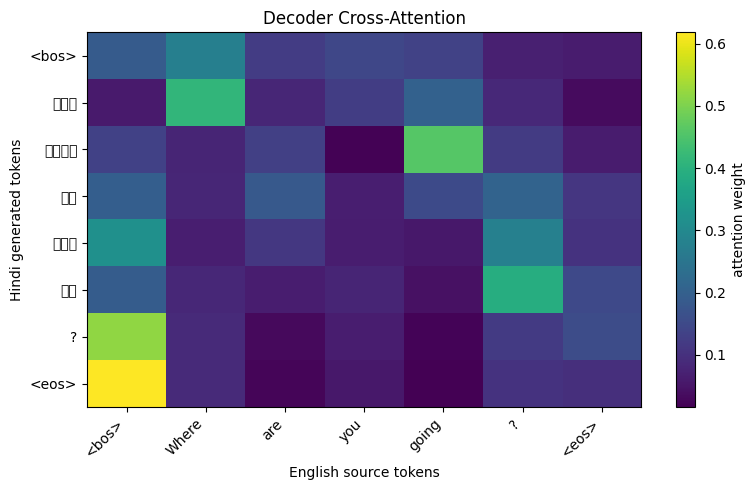

Translation: तुम कहाँ जा रहे हो?


In [29]:
@torch.no_grad()
def visualize_cross_attention(source_text: str) -> None:
    """Plot last-layer cross-attention for one translation."""
    result = greedy_decode_ids(source_text, max_len=data_config.max_seq_len, return_attention=True)
    generated = torch.tensor([result["output_ids"]], dtype=torch.long, device=device)
    src_tokens = [BOS_TOKEN] + result["source_tokens"][: data_config.max_seq_len - 2] + [EOS_TOKEN]
    tgt_tokens = [BOS_TOKEN] + result["output_tokens"]
    if result["output_ids"][-1] != EOS_ID:
        tgt_tokens = tgt_tokens[: len(result["output_ids"])]
    else:
        tgt_tokens = tgt_tokens + [EOS_TOKEN] if tgt_tokens[-1] != EOS_TOKEN else tgt_tokens

    src_ids_tensor = torch.tensor([result["src_ids"]], dtype=torch.long, device=device)
    src_mask = create_src_mask(src_ids_tensor)
    encoder_output, _ = model.encode(src_ids_tensor, src_mask)
    tgt_mask = create_tgt_mask(generated)
    _, _, cross_attentions = model.decode(generated, encoder_output, tgt_mask, src_mask)

    # Last decoder layer, first batch: [heads, target_len, source_len]
    attention = cross_attentions[-1][0].detach().float().cpu()
    attention = attention.mean(dim=0).numpy()  # [target_len, source_len]
    attention = attention[: len(tgt_tokens), : len(src_tokens)]

    plt.figure(figsize=(max(8, len(src_tokens) * 0.6), max(5, len(tgt_tokens) * 0.4)))
    plt.imshow(attention, aspect="auto", cmap="viridis")
    plt.colorbar(label="attention weight")
    plt.xticks(range(len(src_tokens)), src_tokens, rotation=45, ha="right")
    plt.yticks(range(len(tgt_tokens)), tgt_tokens)
    plt.xlabel("English source tokens")
    plt.ylabel("Hindi generated tokens")
    plt.title("Decoder Cross-Attention")
    plt.tight_layout()
    plt.show()
    print("Translation:", result["translation"])


# Run after training.
visualize_cross_attention("Where are you going?")

## 23. Translation Testing

This utility prints source, reference, and model prediction for examples from the validation/test split.

In [30]:
@torch.no_grad()
def show_translation_examples(pairs: list[tuple[str, str]], n: int = 5, use_beam: bool = True) -> None:
    """Print translations for qualitative inspection."""
    model.eval()
    for en_text, hi_ref in pairs[:n]:
        if use_beam:
            pred = beam_search_decode(en_text, beam_size=4, max_len=data_config.max_seq_len)["translation"]
        else:
            pred = greedy_decode_ids(en_text, max_len=data_config.max_seq_len)["translation"]
        print("EN:  ", en_text)
        print("REF: ", hi_ref)
        print("PRED:", pred)
        print("-" * 80)


show_translation_examples(dev_pairs, n=5, use_beam=True)

EN:   No, no, not so fast.
REF:  तुम इतनी आसानी से छूट नहीं सकते.
PRED: नहीं, नहीं, इतना तेजी से नहीं.
--------------------------------------------------------------------------------
EN:   , eject!
REF:  , बेदखल!
PRED: बाहर!
--------------------------------------------------------------------------------
EN:   So we notify the cops about big ticket sales and we even keep half a dozen Ukrainian ex-naval commandos in a van outside, just in case it all kicks off.
REF:  तोहमबड़ीटिकटोंकीबिक्रीकेबारे मेंपुलिस सूचित... / मैं ... और हम भी रखना आधा दर्जन यूक्रेनी पूर्व नौसेना कमांडो...
PRED: तो हम बड़े बिक्री के बारे में पुलिस की बात करते हैं और हम भी एक दर्जन पूर्व पूर्व पूर्व (पूर्व))) की एक दर्जन से बाहर रख देते हैं।
--------------------------------------------------------------------------------
EN:   receiving what their Lord has given them, for they had been virtuous aforetime.
REF:  जो कुछ उनके रब ने उन्हें दिया, वे उसे ले रहे होंगे। निस्संदेह वे इससे पहले उत्तमकारों में से थे
PRED: जो 

## 24. Saving & Loading Model

The checkpoint stores:

- model weights
- optimizer state
- scheduler state
- vocabularies
- configs
- training history

To resume training, run the notebook cells that define the model/vocabs, then call `load_checkpoint` before continuing the training loop.

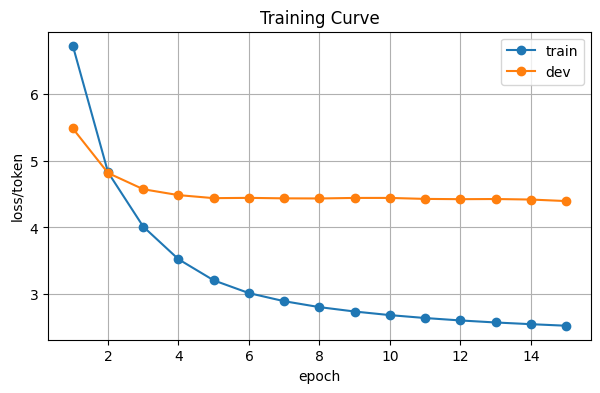

In [31]:
# Example resume usage:
# checkpoint = load_checkpoint(training_config.checkpoint_path)
# history = checkpoint["history"]

# Example save after manual experimentation:
# save_checkpoint(training_config.checkpoint_path, epoch=len(history), history=history)

if history:
    epochs = [item["epoch"] for item in history]
    train_losses = [item["train_loss"] for item in history]
    dev_losses = [item["dev_loss"] for item in history]
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, train_losses, marker="o", label="train")
    plt.plot(epochs, dev_losses, marker="o", label="dev")
    plt.xlabel("epoch")
    plt.ylabel("loss/token")
    plt.title("Training Curve")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No training history yet.")

## 25. Final Analysis

### Transformer Bottlenecks

The main bottleneck is attention. For a sequence length `T`, self-attention creates a token-token matrix:

```text
attention_scores: [batch, heads, T, T]
```

This means time and memory scale as:

```text
O(T^2)
```

Doubling sequence length roughly quadruples attention score memory.

### GPU Memory Scaling

Memory grows with:

```text
batch_size * num_heads * seq_len^2 * num_layers
```

It also grows with activations kept for backpropagation. This is why the notebook uses:

```text
d_model = 256
layers = 3 encoder + 3 decoder
batch_size = 64 with gradient accumulation
max_seq_len = 64
```

These are stronger T4-focused defaults. If CUDA memory runs out, reduce batch size before reducing model size.

### Long-Context Limitations

Classic full attention struggles with long sequences because every token attends to every other token. For translation, long paragraphs become expensive quickly.

### Vanishing and Exploding Gradients

Transformers use residual connections and layer normalization to stabilize gradients. This notebook also adds:

- gradient clipping
- NaN checks
- finite-loss checks
- overfit-small-batch test
- gradient norm monitoring

### Why Transformers Replaced RNNs

RNNs process tokens sequentially, so training is hard to parallelize over time. Transformers process all positions in parallel during training, making GPU utilization much better. Attention also creates direct paths between distant tokens instead of forcing information through many recurrent steps.

### Flash Attention

Flash Attention computes exact attention but avoids materializing the full attention matrix in slow GPU memory. It tiles computation to reduce memory reads/writes. The math is the same; the kernel is smarter.

### Linformer

Linformer approximates attention by projecting keys and values to a lower sequence dimension, reducing attention complexity from roughly `O(T^2)` toward `O(T)` for long sequences.

### Performer

Performer uses kernel methods to approximate softmax attention with linear complexity. It trades exact attention for scalability.

### KV Caching

During autoregressive inference, previous keys and values do not change. KV caching stores them so decoding each new token does not recompute attention over all previous tokens from scratch. This matters heavily for LLM serving.

### Modern LLM Optimizations

Modern systems combine many techniques:

- Flash Attention kernels
- KV caching
- fused operations
- tensor parallelism
- pipeline parallelism
- quantization
- rotary positional embeddings
- RMSNorm or optimized normalization
- grouped-query or multi-query attention
- efficient checkpointing and activation recomputation

This notebook gives you the conceptual base needed to understand those optimizations instead of treating them as magic.